Copyright (c) MONAI Consortium  
Licensed under the Apache License, Version 2.0 (the "License");  
you may not use this file except in compliance with the License.  
You may obtain a copy of the License at  
&nbsp;&nbsp;&nbsp;&nbsp;http://www.apache.org/licenses/LICENSE-2.0  
Unless required by applicable law or agreed to in writing, software  
distributed under the License is distributed on an "AS IS" BASIS,  
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.  
See the License for the specific language governing permissions and  
limitations under the License.

# Understanding K-Space and MRI Reconstruction: A Beginner's Guide

This tutorial introduces the fundamentals of MRI reconstruction using the fastMRI knee single-coil dataset and MONAI. You will learn:

* What k-space is and how it relates to MRI images via the Fourier transform
* Why undersampling k-space causes aliasing artifacts
* How MONAI's reconstruction transforms process k-space data
* How undersampling masks work and their effect on image quality
* How these concepts connect to deep learning-based MRI reconstruction

**Prerequisites:** Basic Python and NumPy. No prior MRI knowledge required.

**Dataset:** [fastMRI](https://fastmri.org/dataset) knee single-coil (requires registration, non-commercial license)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Project-MONAI/tutorials/blob/main/reconstruction/MRI_reconstruction/tutorials/01_kspace_basics_fastmri_knee.ipynb)

## Setup environment

In [ ]:
!python -c "import monai" || pip install -q "monai-weekly[pillow, tqdm]"
!python -c "import matplotlib" || pip install -q matplotlib
!python -c "import h5py" || pip install -q h5py
%matplotlib inline

## Setup imports

In [ ]:
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch

from monai.apps.reconstruction.fastmri_reader import FastMRIReader
from monai.apps.reconstruction.transforms.dictionary import (
    EquispacedKspaceMaskd,
    RandomKspaceMaskd,
    ReferenceBasedNormalizeIntensityd,
)
from monai.config import print_config
from monai.transforms import (
    CenterSpatialCropd,
    Compose,
    EnsureChannelFirstd,
    EnsureTyped,
    Lambdad,
    LoadImaged,
    ThresholdIntensityd,
)
from monai.utils.type_conversion import convert_data_type

print_config()

## About the Dataset

This tutorial uses the [fastMRI](https://fastmri.org/dataset) **knee single-coil** dataset from the NYU fastMRI Initiative.

**Why knee single-coil?**
- Much smaller than brain multi-coil (~19 GB validation set vs. ~1.5 TB)
- No coil combination complexity — lets us focus purely on reconstruction
- Standard entry point in the MRI reconstruction literature

**How to obtain the data:**
1. Register at https://fastmri.org/dataset
2. Download the knee single-coil validation set (`knee_singlecoil_val.tar.gz`)
3. Extract to a folder and update `data_path` in the cell below

**Note:** This dataset is under a non-commercial license. You may not use it for commercial purposes.

**For this tutorial, you only need a single `.h5` file** (~200-400 MB). Each HDF5 file contains:
- `kspace`: Complex-valued k-space data (shape: `[num_slices, height, width]`)
- `reconstruction_esc`: Ground truth images reconstructed from fully-sampled k-space

In [ ]:
# Update this path to where your fastMRI knee single-coil data is stored.
# You only need ONE .h5 file from the knee_singlecoil_val set.
data_path = os.path.join("YOUR_DIR_HERE", "knee_singlecoil_val")

if not os.path.isdir(data_path):
    raise FileNotFoundError(
        f"Data directory not found: {data_path}\n"
        "Please download the fastMRI knee single-coil validation set from "
        "https://fastmri.org/dataset and update the path above."
    )

sample_files = sorted([f for f in os.listdir(data_path) if f.endswith(".h5")])
if len(sample_files) == 0:
    raise FileNotFoundError(
        f"No .h5 files found in {data_path}\n" "Please place at least one .h5 file from the knee_singlecoil_val set."
    )

sample_file = os.path.join(data_path, sample_files[0])
print(f"Using sample file: {sample_file}")
print(f"Total .h5 files found: {len(sample_files)}")

## Part 1: What is K-Space?

MRI scanners do **not** directly capture images. Instead, they measure radio-frequency (RF) signals emitted by hydrogen atoms in the body when placed in a strong magnetic field. These raw measurements live in a domain called **k-space** (spatial frequency domain).

Key intuitions:
- Each point in k-space encodes information about **all** pixels in the image (global frequency information)
- The **inverse Fourier transform** converts k-space data into a viewable image
- Think of it this way: k-space is to an MRI image what a musical recording is to sheet music — same information, different representation

Let's load a real k-space measurement and see what it looks like.

In [ ]:
with h5py.File(sample_file, "r") as hf:
    kspace = hf["kspace"][()]  # shape: (num_slices, height, width)
    ground_truth = hf["reconstruction_esc"][()]
    print(f"K-space shape: {kspace.shape}")
    print(f"K-space dtype: {kspace.dtype}")
    print(f"Ground truth shape: {ground_truth.shape}")

# Select a middle slice for clear anatomy
slice_idx = kspace.shape[0] // 2
kspace_slice = kspace[slice_idx]
gt_slice = ground_truth[slice_idx]
print(f"\nUsing slice {slice_idx} of {kspace.shape[0]}")
print(f"Slice k-space shape: {kspace_slice.shape}")

K-space shape: (35, 640, 368)
K-space dtype: complex64
Ground truth shape: (35, 320, 320)

Using slice 17 of 35
Slice k-space shape: (640, 368)


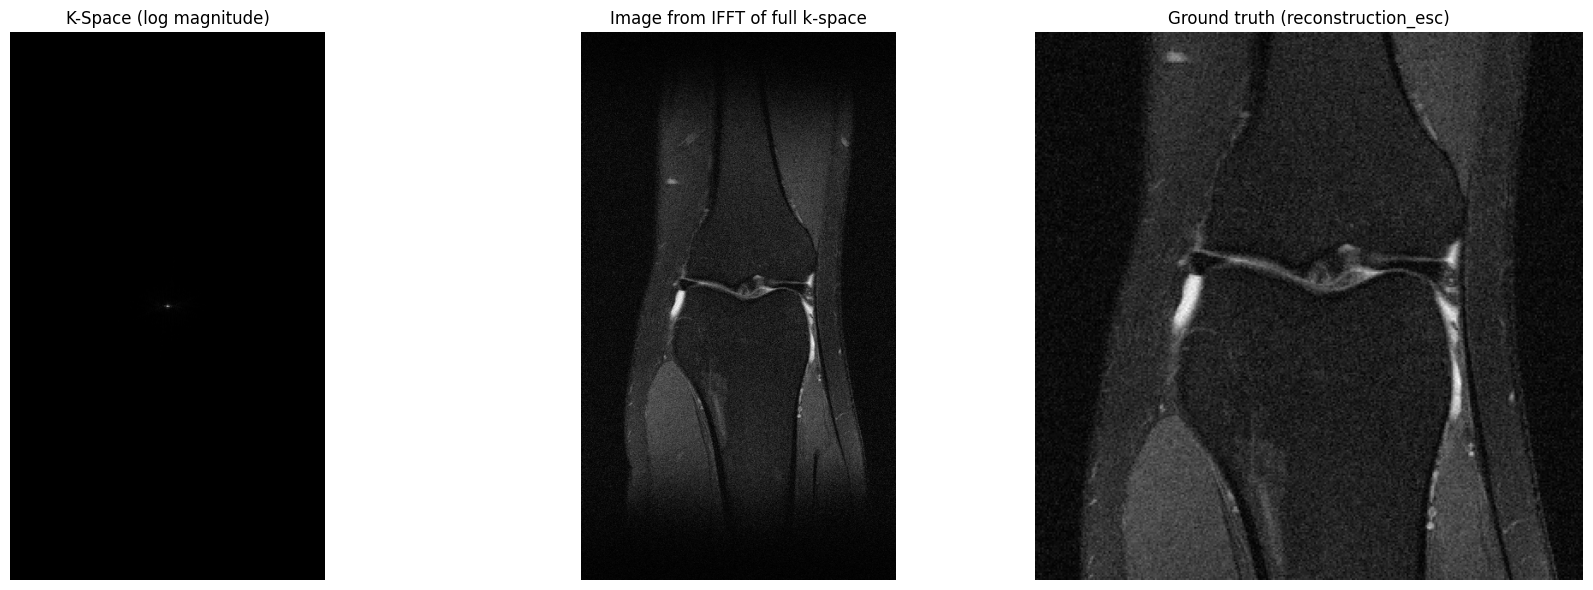

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# K-space magnitude (log scale for visibility)
kspace_mag = np.log1p(np.abs(kspace_slice))
axes[0].imshow(kspace_mag, cmap="gray")
axes[0].set_title("K-Space (log magnitude)")
axes[0].axis("off")

# Reconstruct image via inverse FFT
image_from_kspace = np.fft.ifftshift(np.fft.ifft2(np.fft.fftshift(kspace_slice)))
image_magnitude = np.abs(image_from_kspace)
axes[1].imshow(image_magnitude, cmap="gray")
axes[1].set_title("Image from IFFT of full k-space")
axes[1].axis("off")

# Ground truth
axes[2].imshow(gt_slice, cmap="gray")
axes[2].set_title("Ground truth (reconstruction_esc)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

**What you're seeing:**
- **Left:** Raw k-space data displayed on a log scale. The bright center represents low spatial frequencies; the dimmer edges represent high spatial frequencies.
- **Center:** The image reconstructed by applying the inverse FFT to the full k-space. This is what the MRI scanner would produce with a complete measurement.
- **Right:** The ground truth image provided by fastMRI.

The key takeaway: **k-space and the image are two representations of the same information**, connected by the Fourier transform.

## Part 2: The Fourier Transform Connection

Different regions of k-space encode different types of image information:

- **Center of k-space** = low spatial frequencies = overall contrast, large anatomical structures
- **Edges of k-space** = high spatial frequencies = fine details, sharp edges, tissue boundaries

This is why MRI scans take time — every k-space measurement matters. Let's see what happens when we keep only the center or only the edges.

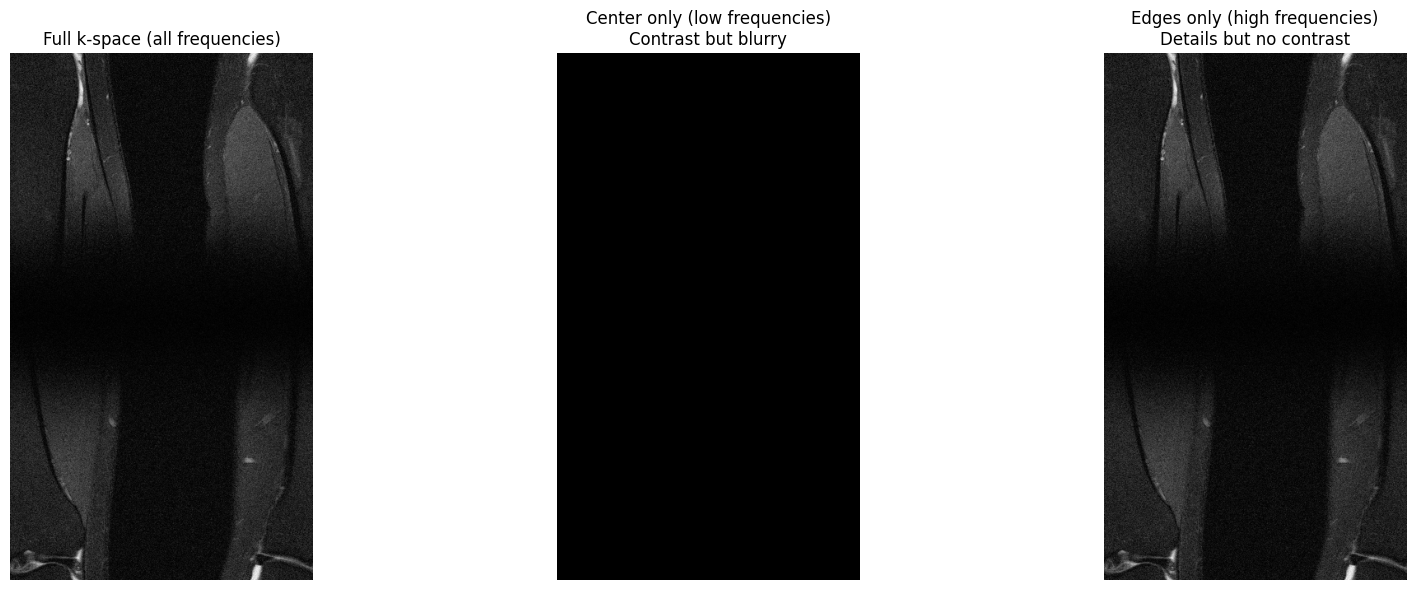

In [ ]:
height, width = kspace_slice.shape
center_fraction = 0.1  # Keep only 10% of k-space in each dimension
center_h = int(height * center_fraction)
center_w = int(width * center_fraction)

# Shift k-space so center (low frequencies) is in the middle
kspace_shifted = np.fft.fftshift(kspace_slice)

# Center-only: keep low frequencies, zero out high frequencies
kspace_center = np.zeros_like(kspace_shifted)
h_start = height // 2 - center_h // 2
w_start = width // 2 - center_w // 2
kspace_center[h_start : h_start + center_h, w_start : w_start + center_w] = kspace_shifted[
    h_start : h_start + center_h, w_start : w_start + center_w
]

# Edges-only: keep high frequencies, zero out center
kspace_edges = kspace_shifted.copy()
kspace_edges[h_start : h_start + center_h, w_start : w_start + center_w] = 0

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(np.abs(np.fft.ifft2(np.fft.ifftshift(kspace_shifted))), cmap="gray")
axes[0].set_title("Full k-space (all frequencies)")
axes[0].axis("off")

axes[1].imshow(np.abs(np.fft.ifft2(np.fft.ifftshift(kspace_center))), cmap="gray")
axes[1].set_title("Center only (low frequencies)\nContrast but blurry")
axes[1].axis("off")

axes[2].imshow(np.abs(np.fft.ifft2(np.fft.ifftshift(kspace_edges))), cmap="gray")
axes[2].set_title("Edges only (high frequencies)\nDetails but no contrast")
axes[2].axis("off")

plt.tight_layout()
plt.show()

**Observations:**
- **Center only:** The image has overall shape and contrast but is very blurry — all fine detail is lost.
- **Edges only:** You can see tissue boundaries and fine structures, but there is no overall contrast or brightness.

Both the center and edges are needed for a complete, diagnostic-quality image. This is the fundamental challenge of accelerated MRI: **how can we acquire fewer k-space measurements while still recovering a high-quality image?**

## Part 3: Why Does Undersampling Cause Aliasing?

A full MRI scan acquires every line of k-space, which is slow. **Accelerated MRI** skips lines to reduce scan time. If we acquire only every $R$-th line, we achieve $R\times$ acceleration (e.g., 4$\times$ means the scan is 4 times faster).

However, the **Nyquist-Shannon sampling theorem** tells us that uniformly skipping lines creates periodic copies (aliases) of the image that overlap. These appear as ghosting artifacts.

Let's see this in action across different acceleration factors.

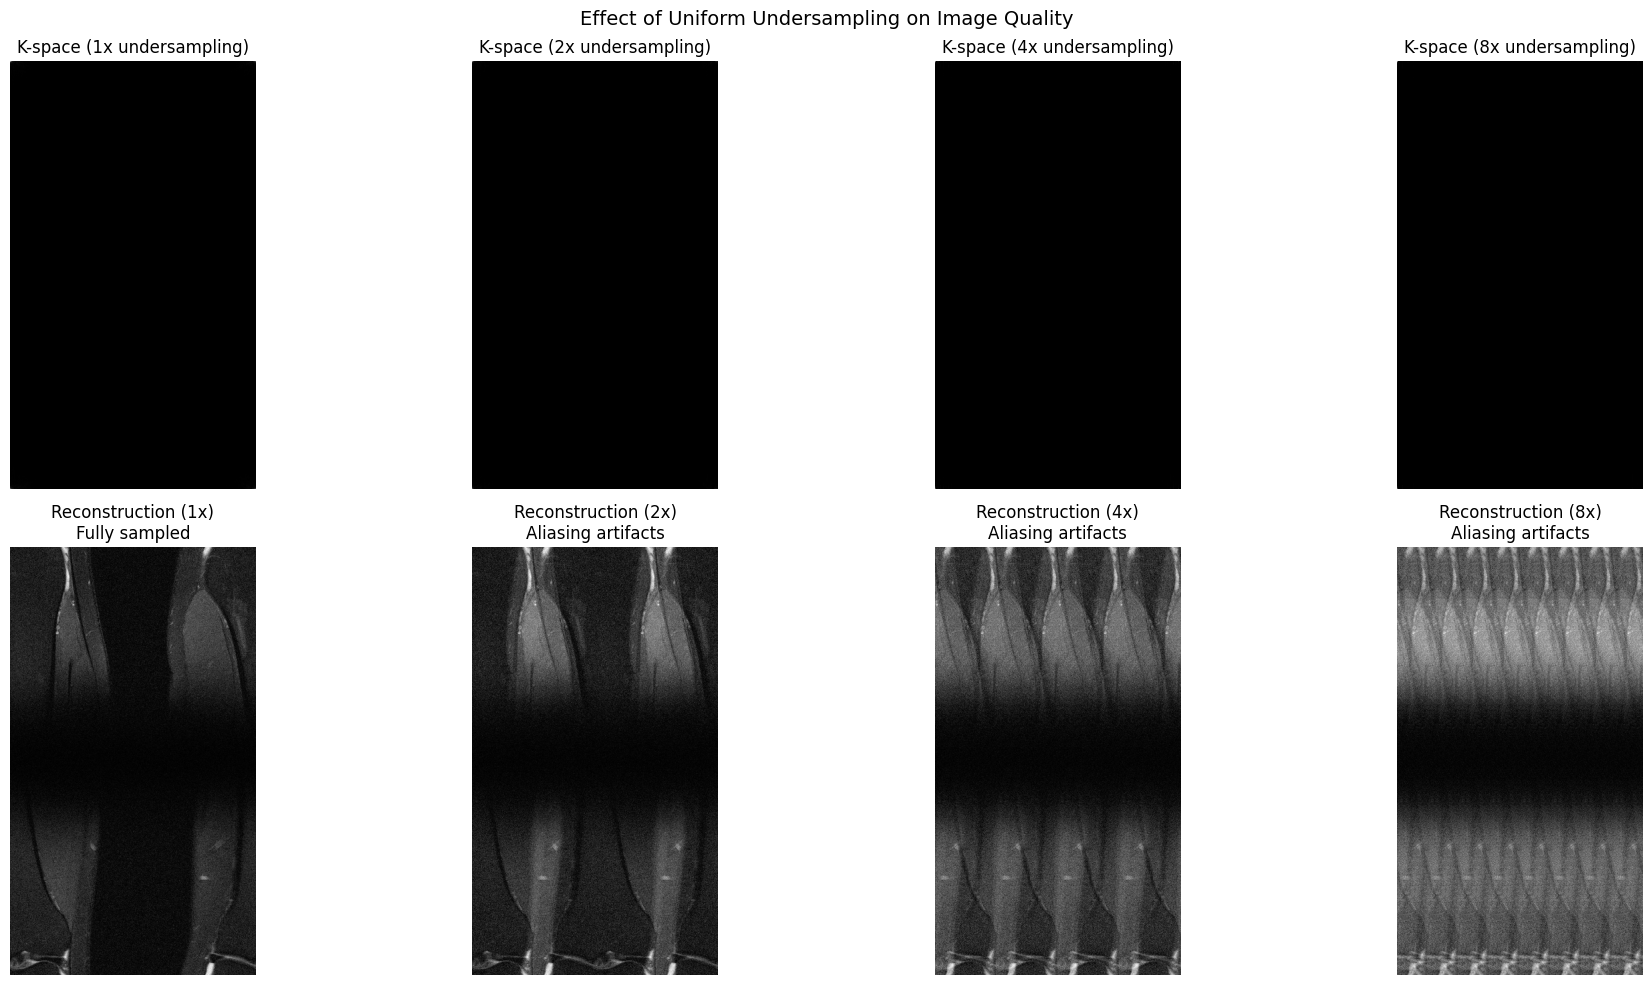

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
accelerations = [1, 2, 4, 8]

kspace_shifted = np.fft.fftshift(kspace_slice)

for idx, accel in enumerate(accelerations):
    # Create uniform undersampling mask (every accel-th line)
    mask = np.zeros(width, dtype=bool)
    mask[::accel] = True

    # Apply mask to k-space columns
    kspace_masked = kspace_shifted.copy()
    kspace_masked[:, ~mask] = 0

    # Show masked k-space (log magnitude)
    axes[0, idx].imshow(np.log1p(np.abs(kspace_masked)), cmap="gray")
    axes[0, idx].set_title(f"K-space ({accel}x undersampling)")
    axes[0, idx].axis("off")

    # Reconstruct via IFFT
    recon = np.abs(np.fft.ifft2(np.fft.ifftshift(kspace_masked)))
    axes[1, idx].imshow(recon, cmap="gray")
    label = "Fully sampled" if accel == 1 else "Aliasing artifacts"
    axes[1, idx].set_title(f"Reconstruction ({accel}x)\n{label}")
    axes[1, idx].axis("off")

plt.suptitle("Effect of Uniform Undersampling on Image Quality", fontsize=14)
plt.tight_layout()
plt.show()

**Key observations:**
- At **1x** (no undersampling), the image is clean.
- At **2x**, faint ghosting appears.
- At **4x**, significant aliasing artifacts are visible — ghosted copies of the anatomy overlap with the true image.
- At **8x**, the image is severely corrupted.

This is the central problem that deep learning-based MRI reconstruction aims to solve: **recovering a clean image from undersampled k-space data.**

## Part 4: Undersampling Masks — Random vs. Equispaced

In practice, MRI reconstruction methods use more sophisticated undersampling patterns:

- **Equispaced:** Skip lines at regular intervals (causes coherent aliasing — repeating ghost patterns)
- **Random:** Skip lines at random positions (causes incoherent aliasing — noise-like artifacts that are easier for algorithms to remove)

Both strategies **always keep the center of k-space fully sampled**, because the low-frequency content is critical for basic image contrast.

MONAI provides both patterns as transforms:
- `RandomKspaceMaskd`: Random undersampling with a fully-sampled center
- `EquispacedKspaceMaskd`: Equispaced undersampling with a fully-sampled center

Let's use these MONAI transforms to compare the two approaches.

In [ ]:
# Both keys point to the same .h5 file; FastMRIReader extracts the
# correct HDF5 dataset based on the key name.
input_dict = {"kspace": sample_file, "reconstruction_esc": sample_file}

base_loader = Compose(
    [
        LoadImaged(
            keys=["kspace", "reconstruction_esc"],
            reader=FastMRIReader,
            image_only=False,
            dtype=np.complex64,
        ),
    ]
)

# Random undersampling pipeline
random_masker = Compose(
    [
        base_loader,
        RandomKspaceMaskd(
            keys=["kspace"],
            center_fractions=[0.08],
            accelerations=[4],
            spatial_dims=2,
            is_complex=True,
        ),
    ]
)

# Equispaced undersampling pipeline
equispaced_masker = Compose(
    [
        base_loader,
        EquispacedKspaceMaskd(
            keys=["kspace"],
            center_fractions=[0.08],
            accelerations=[4],
            spatial_dims=2,
            is_complex=True,
        ),
    ]
)

random_result = random_masker(input_dict.copy())
equispaced_result = equispaced_masker(input_dict.copy())

print("Random mask output keys:", list(random_result.keys()))
print(
    "kspace_masked_ifft shape:",
    random_result["kspace_masked_ifft"].shape,
)

Random mask output keys: ['kspace', 'reconstruction_esc', 'kspace_meta_dict', 'reconstruction_esc_meta_dict', 'kspace_masked', 'kspace_masked_ifft', 'mask']
kspace_masked_ifft shape: torch.Size([640, 368])


In [ ]:
def as_numpy(x):
    """Convert torch tensor or array to numpy using MONAI utility."""
    arr, *_ = convert_data_type(x, np.ndarray)
    return arr


fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: Random mask
rand_mask = as_numpy(random_result["mask"]).squeeze()
axes[0, 0].imshow(np.tile(rand_mask, (64, 1)), cmap="gray", aspect="auto")
axes[0, 0].set_title("Random mask pattern")
axes[0, 0].axis("off")

rand_recon = as_numpy(random_result["kspace_masked_ifft"])
if rand_recon.ndim == 3:
    rand_recon = rand_recon[rand_recon.shape[0] // 2]
rand_recon = np.abs(rand_recon.squeeze())
axes[0, 1].imshow(rand_recon, cmap="gray")
axes[0, 1].set_title("Zero-filled recon (random 4x)")
axes[0, 1].axis("off")

gt = np.abs(as_numpy(ground_truth[slice_idx]))
axes[0, 2].imshow(gt, cmap="gray")
axes[0, 2].set_title("Ground truth")
axes[0, 2].axis("off")

# Row 2: Equispaced mask
equi_mask = as_numpy(equispaced_result["mask"]).squeeze()
axes[1, 0].imshow(np.tile(equi_mask, (64, 1)), cmap="gray", aspect="auto")
axes[1, 0].set_title("Equispaced mask pattern")
axes[1, 0].axis("off")

equi_recon = as_numpy(equispaced_result["kspace_masked_ifft"])
if equi_recon.ndim == 3:
    equi_recon = equi_recon[equi_recon.shape[0] // 2]
equi_recon = np.abs(equi_recon.squeeze())
axes[1, 1].imshow(equi_recon, cmap="gray")
axes[1, 1].set_title("Zero-filled recon (equispaced 4x)")
axes[1, 1].axis("off")

axes[1, 2].imshow(gt, cmap="gray")
axes[1, 2].set_title("Ground truth")
axes[1, 2].axis("off")

plt.suptitle(
    "Random vs. Equispaced Undersampling (4x acceleration)",
    fontsize=14,
)
plt.tight_layout()
plt.show()

**Observations:**
- **Random mask:** The sampled lines are irregularly spaced (with a dense center). Aliasing artifacts appear as noise-like patterns.
- **Equispaced mask:** The sampled lines are evenly spaced (with a dense center). Aliasing artifacts appear as coherent ghost copies.

Random undersampling is generally preferred for compressed sensing and deep learning reconstruction because incoherent artifacts are easier for algorithms to suppress than coherent ghosts.

## Part 5: The MONAI Reconstruction Pipeline

MONAI provides a complete set of transforms for MRI reconstruction workflows. The existing [U-Net demo](../unet_demo/) and [VarNet demo](../varnet_demo/) use these transforms in production training pipelines. Here we walk through each step to understand what they do.

The full pipeline is:

1. **`LoadImaged`** with `FastMRIReader` — reads HDF5 files, extracts k-space as complex-valued tensor
2. **Select a single slice** — each `.h5` file contains a full volume; we pick the middle slice
3. **`RandomKspaceMaskd`** — applies an undersampling mask and computes zero-filled reconstruction (`kspace_masked_ifft`)
4. **`CenterSpatialCropd`** — crops to 320x320 to match the ground truth spatial dimensions
5. **`ReferenceBasedNormalizeIntensityd`** — normalizes intensity values using a reference image
6. **`ThresholdIntensityd`** — clamps extreme values to a fixed range

The output `kspace_masked_ifft` (zero-filled reconstruction) becomes the **input** to a neural network, and `reconstruction_esc` (ground truth) becomes the **target**.

In [ ]:
def take_middle_slice(x):
    """Select the middle slice from a volume: (S, H, W) -> (1, H, W)."""
    if hasattr(x, "shape") and len(x.shape) >= 3:
        mid = x.shape[0] // 2
        return x[mid : mid + 1]
    return x


def complex_to_magnitude(x):
    """Take magnitude if complex; otherwise return as-is."""
    x = np.asarray(x)
    return np.abs(x) if np.iscomplexobj(x) else x


# Stage 1: Load, select middle slice, apply undersampling mask
pre_transform = Compose(
    [
        LoadImaged(
            keys=["kspace", "reconstruction_esc"],
            reader=FastMRIReader,
            image_only=False,
            dtype=np.complex64,
        ),
        Lambdad(
            keys=["kspace", "reconstruction_esc"],
            func=take_middle_slice,
        ),
        RandomKspaceMaskd(
            keys=["kspace"],
            center_fractions=[0.08],
            accelerations=[4],
            spatial_dims=2,
            is_complex=True,
        ),
        Lambdad(
            keys=["kspace_masked_ifft"],
            func=lambda x: (torch.abs(x) if isinstance(x, torch.Tensor) and torch.is_complex(x) else x),
        ),
    ]
)

# Stage 2: Shape fixes, crop to 320x320, normalize, clamp
post_transform = Compose(
    [
        EnsureChannelFirstd(
            keys=["kspace_masked_ifft"],
            channel_dim="no_channel",
        ),
        CenterSpatialCropd(
            keys=["kspace_masked_ifft", "reconstruction_esc"],
            roi_size=(320, 320),
        ),
        Lambdad(keys=["kspace_masked_ifft"], func=complex_to_magnitude),
        ReferenceBasedNormalizeIntensityd(
            keys=["kspace_masked_ifft", "reconstruction_esc"],
            ref_key="kspace_masked_ifft",
            channel_wise=True,
        ),
        ThresholdIntensityd(
            keys=["kspace_masked_ifft", "reconstruction_esc"],
            threshold=6.0,
            above=False,
            cval=6.0,
        ),
        ThresholdIntensityd(
            keys=["kspace_masked_ifft", "reconstruction_esc"],
            threshold=-6.0,
            above=True,
            cval=-6.0,
        ),
        EnsureTyped(
            keys=["kspace_masked_ifft", "reconstruction_esc"],
        ),
    ]
)

data = pre_transform(input_dict.copy())
result = post_transform(data)

print("Pipeline output keys:", list(result.keys()))
print(f"Input shape (kspace_masked_ifft): " f"{result['kspace_masked_ifft'].shape}")
print(f"Target shape (reconstruction_esc): " f"{result['reconstruction_esc'].shape}")

Pipeline output keys: ['kspace', 'reconstruction_esc', 'kspace_meta_dict', 'reconstruction_esc_meta_dict', 'kspace_masked', 'kspace_masked_ifft', 'mask', 'mean', 'std']
Input shape (kspace_masked_ifft): torch.Size([1, 320, 320])
Target shape (reconstruction_esc): torch.Size([1, 320, 320])


## Part 6: From Zero-Filled to Deep Learning

The zero-filled reconstruction is the starting point for deep learning methods. A neural network learns to map the degraded zero-filled image to the clean ground truth.

- **U-Net approach** (see [U-Net demo](../unet_demo/)): Treats reconstruction as an image-to-image translation task. The zero-filled image goes in; a clean image comes out.
- **VarNet approach** (see [VarNet demo](../varnet_demo/)): Iterates between data consistency in k-space and image refinement, using cascaded networks.

Let's visualize the problem these networks are trained to solve.

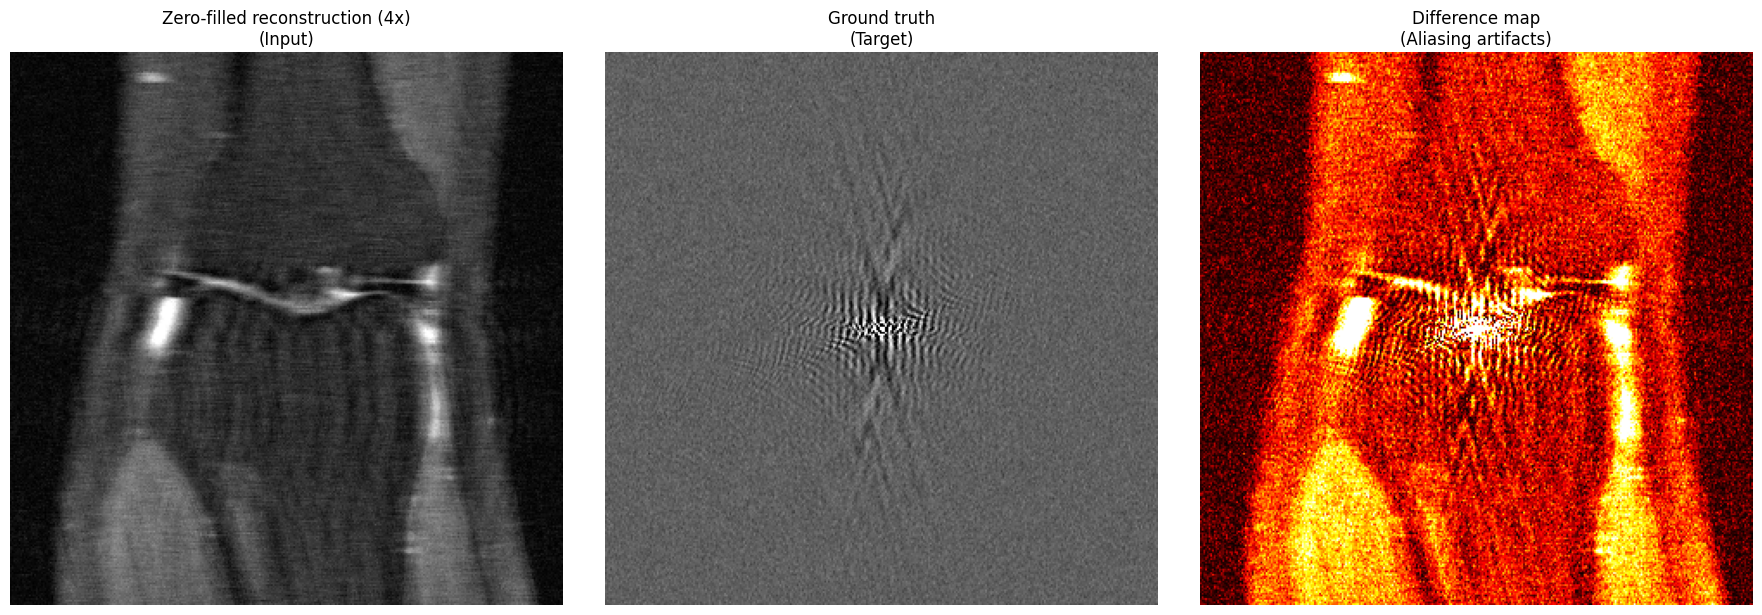

In [ ]:
def as_numpy_2d(x):
    """Return a 2D numpy image from (1, H, W) torch/numpy."""
    arr, *_ = convert_data_type(x, np.ndarray)
    return arr[0] if arr.ndim == 3 else arr


input_img = as_numpy_2d(result["kspace_masked_ifft"])
target_img = as_numpy_2d(result["reconstruction_esc"])

diff = np.abs(input_img - target_img)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(input_img, cmap="gray")
axes[0].set_title("Zero-filled reconstruction (4x)\nInput to neural network")
axes[0].axis("off")

axes[1].imshow(target_img, cmap="gray")
axes[1].set_title("Ground truth\nTarget for training")
axes[1].axis("off")

axes[2].imshow(diff, cmap="hot", vmax=np.max(diff) * 0.5)
axes[2].set_title("Difference map\nWhat the network must learn")
axes[2].axis("off")

plt.suptitle("The MRI Reconstruction Problem", fontsize=14)
plt.tight_layout()
plt.show()

**What you see:**
- **Left:** The zero-filled reconstruction after the full MONAI preprocessing pipeline. This is what gets fed into a neural network.
- **Center:** The ground truth image. This is what the network is trained to produce.
- **Right:** The difference map (hot colormap). Bright regions show where the zero-filled reconstruction differs most from the ground truth — these are the aliasing artifacts the network must learn to remove.

For production training pipelines that train U-Net and VarNet models on this type of data, see the companion demos:
- [U-Net demo](../unet_demo/) — `BasicUNet` achieving 0.9436 SSIM on brain multi-coil
- [VarNet demo](../varnet_demo/) — end-to-end Variational Network achieving 0.9650 SSIM on brain multi-coil

## Summary

In this tutorial, you learned:

1. **K-space** is the spatial frequency domain where MRI scanners acquire data. The inverse Fourier transform converts it to an image.
2. **Low frequencies** (center of k-space) encode contrast and large structures; **high frequencies** (edges) encode fine details.
3. **Undersampling** k-space speeds up MRI scans but causes aliasing artifacts due to the Nyquist-Shannon theorem.
4. **Random undersampling** produces incoherent artifacts (easier to remove) vs. **equispaced** which produces coherent ghosts.
5. MONAI provides a complete **reconstruction transform pipeline** (`FastMRIReader` -> `RandomKspaceMaskd` -> `CenterSpatialCropd` -> normalization) to prepare data for deep learning.
6. The **zero-filled reconstruction** is the input to neural networks that learn to remove aliasing artifacts.

### Next Steps

- Try changing the `accelerations` parameter (e.g., `[8]`) and `center_fractions` (e.g., `[0.04]`) to see how they affect image quality
- Explore the [U-Net demo](../unet_demo/) to see how `BasicUNet` is trained for MRI reconstruction
- Explore the [VarNet demo](../varnet_demo/) to see a more advanced approach using data consistency cascades

## Acknowledgment

Data used in the preparation of this tutorial were obtained from the NYU fastMRI Initiative database (fastmri.med.nyu.edu). [Citation: Knoll et al., Radiol Artif Intell. 2020 Jan 29;2(1):e190007. doi: 10.1148/ryai.2020190007. (https://pubs.rsna.org/doi/10.1148/ryai.2020190007), and the arXiv paper: https://arxiv.org/abs/1811.08839] As such, NYU fastMRI investigators provided data but did not participate in analysis or writing of this tutorial. A listing of NYU fastMRI investigators, subject to updates, can be found at: fastmri.med.nyu.edu. The primary goal of fastMRI is to test whether machine learning can aid in the reconstruction of medical images.